In [10]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torchvision import transforms as T
from torch import optim

import itertools

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
    create_data_loaders,
)
from tqpmod.tqp_optimizer_scale_train import TQPS
# from tqpmod.softbinning import SoftBinning # replace with custom
from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import train_epoch, evaluate

DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt


In [11]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)

In [12]:
@torch.compile()
@torch.no_grad()
def calc_reg_loss_scale_layer(
    optimizer,
    soft_binning: SoftBinningScale,
    n_params,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)

    for group in optimizer.get_regularized_param_groups():
        if group["quant_bits"] == 0:
            for param in group["params"]:

                reg_loss += soft_binning.call_test(param).sum().detach()

                calc_param = param.detach()
                quantized_params += (
                    (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
                    .sum()
                    .to(torch.int64)
                )

                norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item()

In [13]:
@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

In [14]:
import numpy as np


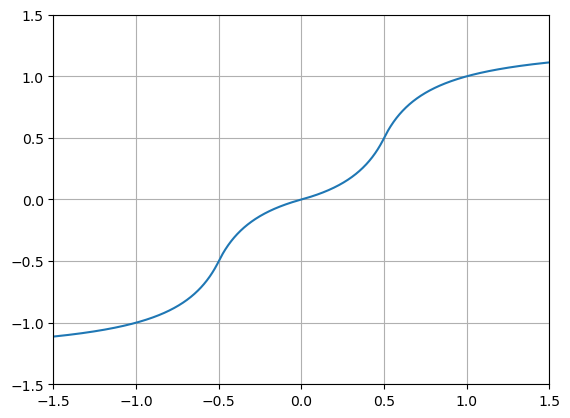

In [15]:
def prox_map(x, a):
    sign_x = torch.sign(x)
    y = x.abs()
    sign_y = 2 * (y >= 0.5) - 1 # equal to: # torch.sign(y - 0.5);sign_y[sign_y==0] = 1
    y = sign_y * 2 * y - sign_y
    y = ((1-y) / (1 + y * (torch.exp(a) -1)) ) 
    y = y * 0.5 * -sign_y + (1 * (sign_y==1))
    return y * sign_x

x = torch.linspace(-1.5,1.5,1000)
# y = (prox_map(x,torch.ones(()) )* 0.5) * -sign  + (1 * (sign==1))
y = prox_map(x,torch.ones(()) * 1.)
plt.plot(x.cpu(),y.cpu())
plt.xlim((-1.5,1.5))
plt.ylim((-1.5,1.5))
plt.grid()

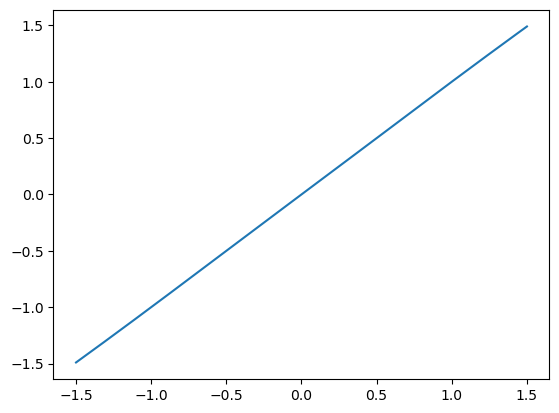

In [16]:
@torch.no_grad()
@torch.compile()
def tanhmod_map(x: torch.Tensor, lambda_factor:torch.Tensor | float = 1.):
    x_shape = x.shape
    y = x.flatten(1)
    y = y.to(torch.float64)
    x_sign = y.sign()
    y = y.abs()
    y = ((y *2  ) - 1)

    one = torch.ones(()).to(dtype=torch.float64) # scale_factor
    
    correction_factor = ((torch.exp(lambda_factor * one) - torch.exp(lambda_factor * -one))) / (
        torch.exp(lambda_factor * one) + torch.exp(lambda_factor * -one)
    )
    return(( (
        (
            (
                ((torch.exp(lambda_factor * y) - torch.exp(lambda_factor * -y)))
                / (torch.exp(lambda_factor * y) + torch.exp(lambda_factor * -y))
                / correction_factor
            )
        + 1
        )
        * 0.5
        
    ) * x_sign).to(torch.float32)).reshape(x_shape) # 

@torch.no_grad()
def tanh_list(params,beta):
    for param in params:
        param.copy_(tanhmod_map(param.data,beta))
    
x = torch.linspace(-1.5,1.5,1000).reshape((-1,1))
y = tanhmod_map(x,0.1).flatten()
x = x.flatten()
plt.plot(x.cpu(),y.cpu())

In [17]:
from tqpmod.tqp_optimizer_scale_train import apply_prox_hard_rounding_list_scale_layer
def tanh_test(params, beta):
    if beta < 1.0:
        tanh_list(
            params,
            beta=beta,
        )
    else:
        apply_prox_hard_rounding_list_scale_layer(params, beta=beta)

@torch.compile()
@torch.no_grad()
def prox_lin_map(x:torch.Tensor,beta:float):
    round = x.round()
    y = torch.where( (x - round.clip(-1,1)).abs() < 2*beta, round.clip(-1,1),x)
    sign = - x.sign()
    sign = torch.where((x.abs() > 0.5) & (x.abs() < 1.0),-sign,sign)
    y = torch.where(y!= round.clip(-1,1),x+2*beta *sign,y)
    return y

@torch.compile()
@torch.no_grad()
def prox_lin_test(params,beta):
    """only works for beta <=0.25
    with bigger beta, rounding 
    """
    if beta <= 0.25:
        for param in params:
            param.copy_(prox_lin_map(param.data,beta))
    else:
         apply_prox_hard_rounding_list_scale_layer(params, beta=beta)

@torch.compile()
@torch.no_grad()
def prox_bin_test(params:list[nn.Parameter],beta):
    if beta <= 0.5:
        for param in params:
            param.copy_(prox_binary_map(param.data,beta))
    else:
        for param in params:
            param.sign_()




@torch.compile()
@torch.no_grad()
def prox_binary_map(x:torch.Tensor,beta):
    x = torch.as_tensor(x)
    y = (x/(1-beta*2)).clip(-1,1)
    y = torch.where(abs(x)>1+beta,x / (1+2*beta) + x.sign() * (1-((1+beta) / (1+2*beta))),y)
    return y



In [18]:
from tqpmod.model_utils import inject_scale_layers, rebalance_layers


def longrun_scale_layer(beta,train_params, run_name: str = "ScaleLayerTrain"):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "reg_loss": [],
            "norm": [],
            "factor_avg": [],
            "beta":[]
        }
        num_epochs = 300 # 1000  # like 310
        num_epochs_lr_schedule = 299 # 999 # 300
        learning_rate = 0.1
        weight_decay = 2e-4

        SEED = torch.randint(0, 10000, (1,))

        torch.manual_seed(SEED)
        batch_size = 64
        train_loader, val_loader = create_data_loaders(
            "~/data",
            batch_size,
            11,
            False,
            SEED,
        )
        steps_per_epoch = len(train_loader)

        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        model = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
        param_groups = [] 
        # TOD: 
        rest_group = []
        names = {
            param: name for name, param in model.named_parameters()
        }  # for debugging

        inject_scale_layers(
            model,
            param_groups,
            factor_function=factor_function_test,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            scale_grad=False,
        )
        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        param_groups_list = []
        for param_group in param_groups:
            param_groups_list.extend([id(param) for param in param_group["params"]])

        for name, param in model.named_parameters():
            if id(param) not in param_groups_list:
                rest_group.append(param)
        param_groups.append(
            {"params": rest_group, "weight_decay": 0, learning_rate: learning_rate}
        )

        lr_warmup_epochs = 10
        def get_lr_factor(epoch):
            if epoch < lr_warmup_epochs:
                return (epoch + 1) / lr_warmup_epochs
            elif epoch > num_epochs_lr_schedule:
                return get_lr_factor(num_epochs_lr_schedule)
            else:
                return max(
                    [
                        0.5
                        * (
                            1
                            + np.cos(
                                np.pi
                                * (epoch - lr_warmup_epochs)
                                / (num_epochs_lr_schedule - lr_warmup_epochs)
                            )
                        ),
                        1e-9,
                    ]
                )

        base_optimizer = torch.optim.SGD(
            param_groups,
            learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            base_optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0
        best_reg_loss = float("inf")

        REG_wait_epochs = 35 
        optimizer = TQPS(
            base_optimizer,
            len(train_loader),
            reg_wait_epochs=REG_wait_epochs,
            regularization_epochs=num_epochs,
            beta = beta,
            logger=logger,
            #reg_function_=tanh_test,
            #reg_function_=prox_lin_test
            reg_function_=prox_bin_test
        )
        optimizer.base_optimizer.zero_grad()

        n_reg_params = sum([torch.numel(x) for x in optimizer.regularized_params])
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "REG_wait_epochs": REG_wait_epochs,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "base_optimizer_state_dict": base_optimizer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_reg_loss": best_reg_loss,
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="ResNet-TQP",
            name=f"{run_name}-{beta}",
            config={
                "architecture": "ResNet20",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": base_optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": beta,
                "reg_wait_epochs": REG_wait_epochs,
                "label_smoothing": label_smoothing,
                "note": "every epoch factor, dont wait",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {base_optimizer.param_groups[0]['lr']:.10f}"
                )

                if epoch == num_epochs - 1:
                   optimizer.set_final_beta()
                   logger.warning("DISABLED GRAD ON REG-PARAMS")
                   logger.info("overwrote beta to 1 for final epoch")

                # Train
                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    epoch == 10,
                    epoch,
                    amp=True,
                )
                # TODO: compute change rate

                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                if epoch == REG_wait_epochs -1: #TODO: check one off error
                # if epoch == 44: #TODO: check one off error
                    # logger.warning("WARNING, REBALANCE EPOCH HARDCODED!!!!!\n!\n!\n!\n!")
                    param_dict = {
                        group["params"][0]: {"index": index, "group": group}
                        for index, group in enumerate(optimizer.param_groups)
                        if len(group["params"]) == 1
                    }
                    # param_dict is needed because rebalance needs to know each parameter_groups index in the lr_schedulers base_lrs list.
                    # the group itself is also needed to adjust weight decay.
                    rebalance_layers(
                        model,
                        param_dict,
                        lr_scheduler,
                        optimizer,
                        factor_function=factor_function_test,
                    )
                lr_scheduler.step()

                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                reg_loss, norm, share_done = calc_reg_loss_scale_layer(
                    optimizer, soft_binning, n_reg_params, beta=beta
                )


                # decay beta based on finished_rate
                if epoch > 11 and optimizer.beta != 1.0:
                    new_beta = (1-share_done) * beta + share_done * (beta * 1e-2)
                    new_beta = min(new_beta,history["beta"][-1])
                    if isinstance(optimizer.beta,torch.Tensor):
                        optimizer.beta.copy_(new_beta)
                    else:
                        optimizer.beta = torch.tensor(new_beta,device=DEVICE,requires_grad=False)
                else:
                    new_beta=beta
                # Save history
                history["beta"].append(new_beta)
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)


                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Reg Loss: {reg_loss:.4f}"
                )

                history["reg_loss"].append(reg_loss)
                history["norm"].append(norm)

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "reg_loss": reg_loss,
                    "norm": norm,
                    "beta": optimizer.beta,
                    "share_done": share_done,
                }

                if epoch % 2 == 0:
                    # this means that if we choose even numbers for num_epochs, we will evaluate
                    # after the last epoch.
                    pass
                else:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])

                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if reg_loss < best_reg_loss:
                        best_reg_loss = reg_loss
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "REG_wait_epochs": REG_wait_epochs,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "base_optimizer_state_dict": base_optimizer.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "reg_loss": reg_loss,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_reg_loss": best_reg_loss,
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best reg_loss: {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat reg_loss: {reg_loss:.3f} vs {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )

                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)
            # wandb context
            # if epoch == 10:
            #     break
    except Exception as e:

        logger.error("error: ", e)
    return history, model, optimizer

In [ ]:
for i in range(4):
    hist, model,optimizer = longrun_scale_layer(1e-4,{},"prox_bin_test")

2026-07-13 16:12:07 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-13 16:12:09 [INFO] 
Epoch [1/300] | LR: 0.8319296837
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:20<00:00, 37.72it/s]
2026-07-13 16:12:31 [INFO] Train Loss: 1.6790 | Train Acc: 44.53% | Reg Loss: 0.4016
2026-07-13 16:12:31 [INFO] Epoch Time: 21.89s
2026-07-13 16:12:31 [INFO] 
Epoch [2/300] | LR: 1.6638593674
Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:03<00:00, 223.64it/s]
2026-07-13 16:12:34 [INFO] Train Loss: 1.3523 | Train Acc: 61.99% | Reg Loss: 0.6038
Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 21.16it/s]
2026-07-13 16:12:42 [INFO] Test Loss: 1.2853 | Test Acc: 67.89%
2026-07-13 16:12:42 [INFO] ✓ Saved best model with best reg_loss: 0.604, accuracy: 67.89%
2026-07-13 16:12:42 [INFO] Epoch Time: 10.94s
2026-07-1

(array([219.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 213.]),
 array([-1.        , -0.80000001, -0.60000002, -0.39999998, -0.19999999,
         0.        ,  0.20000005,  0.39999998,  0.60000002,  0.80000007,
         1.        ]),
 <BarContainer object of 10 artists>)

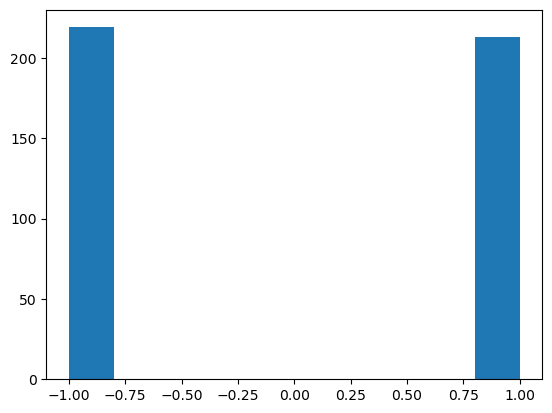

In [22]:
plt.hist(model.conv1[0].weight.detach().cpu().flatten())

In [29]:
hist, model,optimizer = longrun_scale_layer(1e-4,{},"linear_test_no_endbeta")

2026-07-13 00:47:48 [WARNING] Starting logging...


2026-07-13 00:47:49 [INFO] 
Epoch [1/300] | LR: 0.7798282504
Training: 100%|██████████| 781/781 [00:03<00:00, 203.48it/s]
2026-07-13 00:47:54 [INFO] Train Loss: 1.6446 | Train Acc: 46.40% | Reg Loss: 0.4011
2026-07-13 00:47:54 [INFO] Epoch Time: 4.75s
2026-07-13 00:47:54 [INFO] 
Epoch [2/300] | LR: 1.5596565008
Training: 100%|██████████| 781/781 [00:02<00:00, 269.60it/s]
2026-07-13 00:47:57 [INFO] Train Loss: 1.3514 | Train Acc: 62.00% | Reg Loss: 0.5893
Evaluating: 100%|██████████| 157/157 [00:01<00:00, 149.03it/s]
2026-07-13 00:47:58 [INFO] Test Loss: 1.3703 | Test Acc: 63.26%
2026-07-13 00:47:58 [INFO] ✓ Saved best model with best reg_loss: 0.589, accuracy: 63.26%
2026-07-13 00:47:58 [INFO] Epoch Time: 3.98s
2026-07-13 00:47:58 [INFO] 
Epoch [3/300] | LR: 2.3394849300
Training: 100%|██████████| 781/781 [00:02<00:00, 266.48it/s]
2026-07-13 00:48:01 [INFO] Train Loss: 1.2128 | Train Acc: 68.98% | Reg Loss: 0.8799
2026-07-13 00:48:01 [INFO] Epoch Time: 2.94s
2026-07-13 00:48:01 [INFO] 

beta,██████████████████████████████▇▇▆▆▆▄▂▂▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
epoch time:,▄▁▁▁▁▁▁█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▃▂▂▂▂▂▂▃▆▆
lr,▂████████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
norm,▂▄▇████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg_loss,▆██▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
share_done,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▅▆▆██
test_acc,▁▂▃▅▅▅▅▄▆▅▅▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇██████████████
test_loss,█▅▄▄▃▃▄▅▄▃▃▄▄▄▃▃▃▃▃▃▃▂▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▄▄▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
+1,...


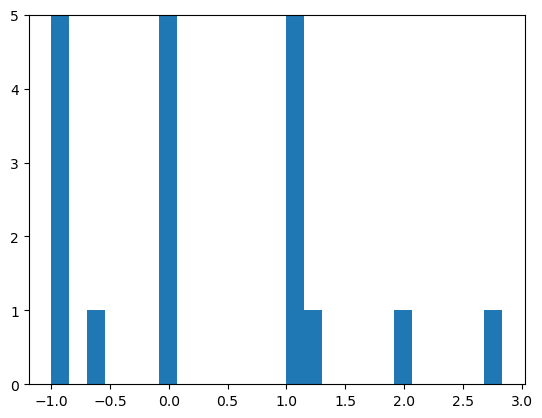

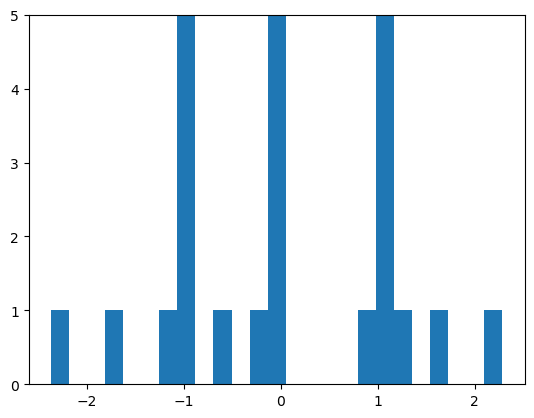

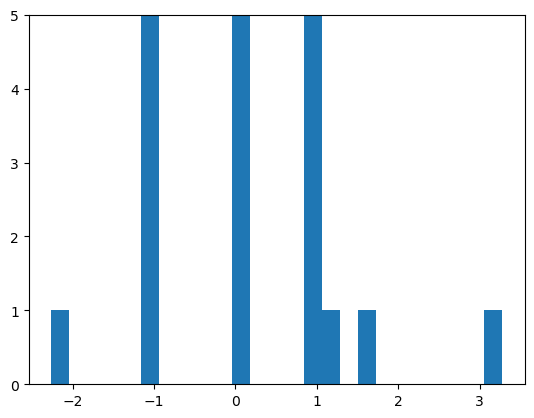

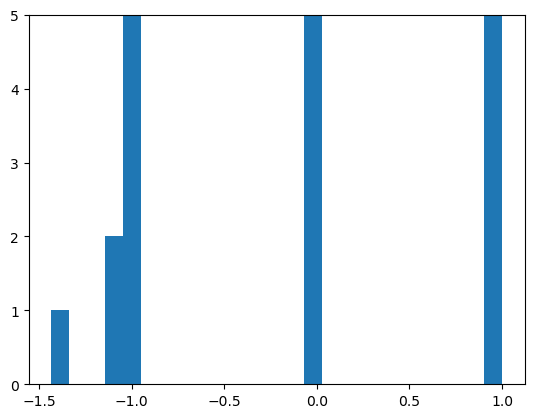

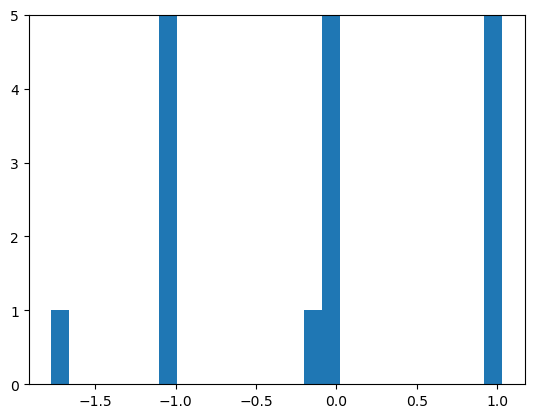

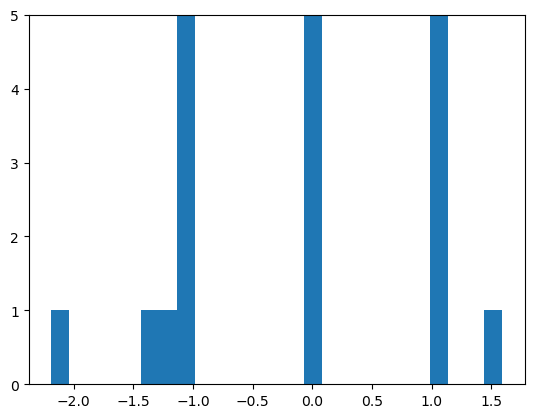

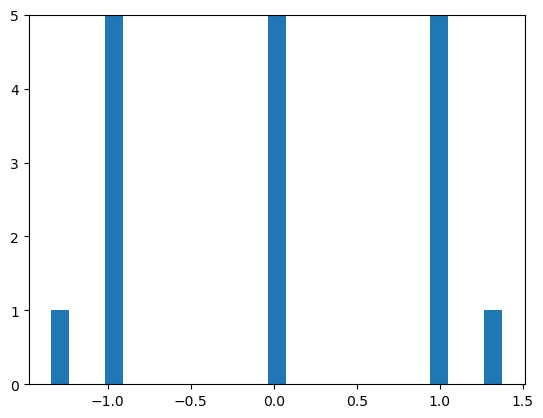

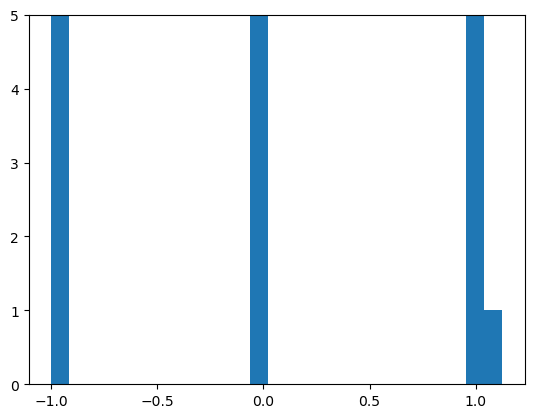

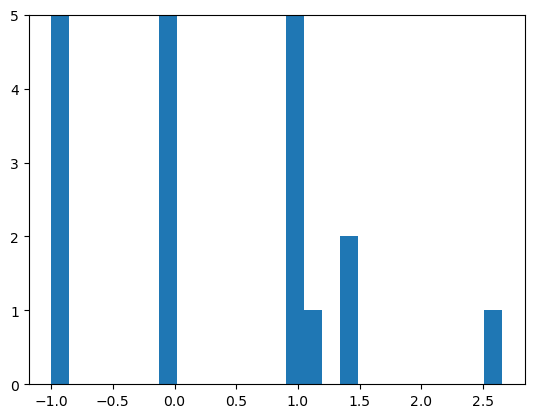

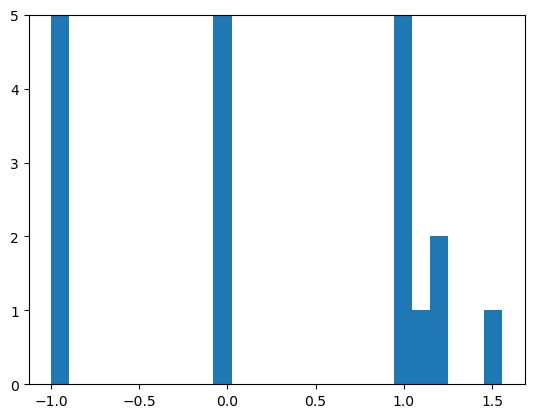

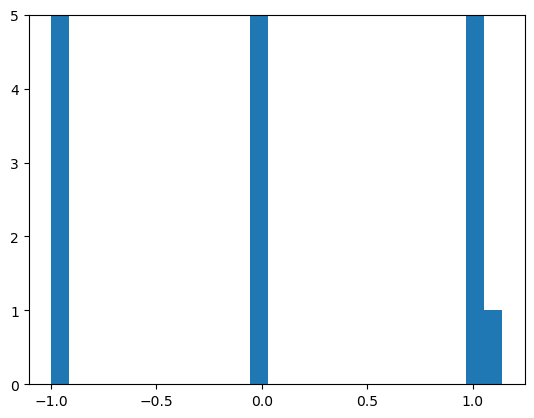

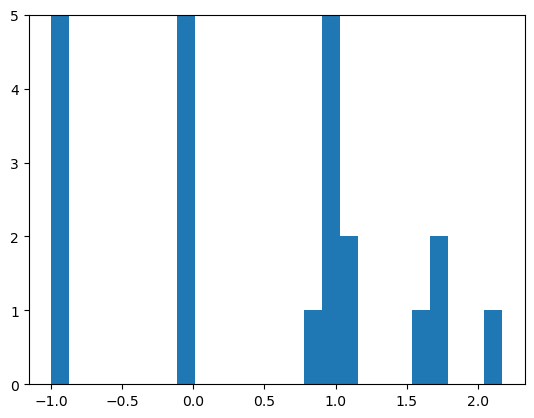

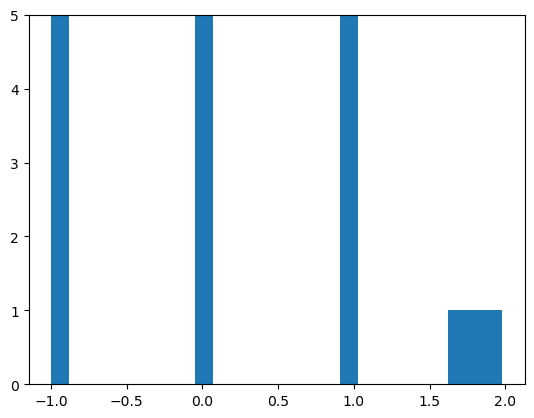

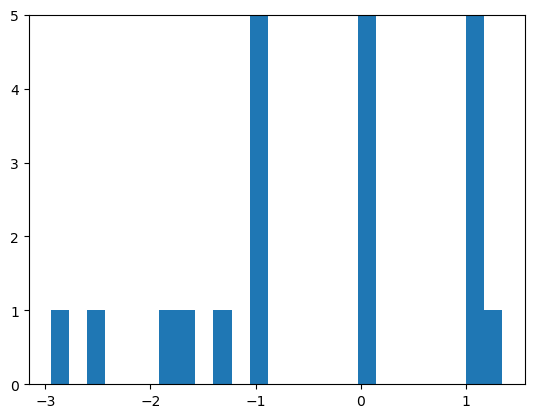

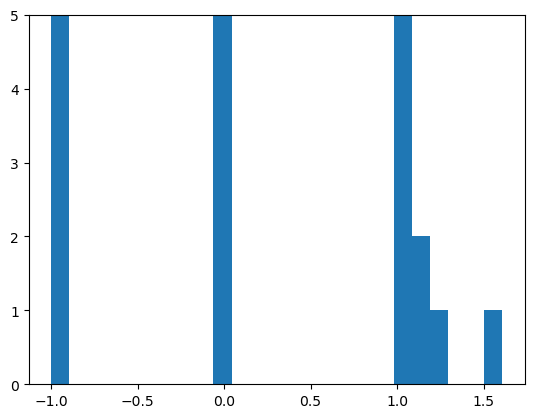

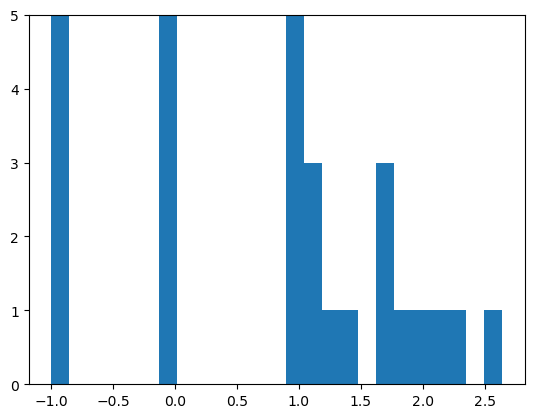

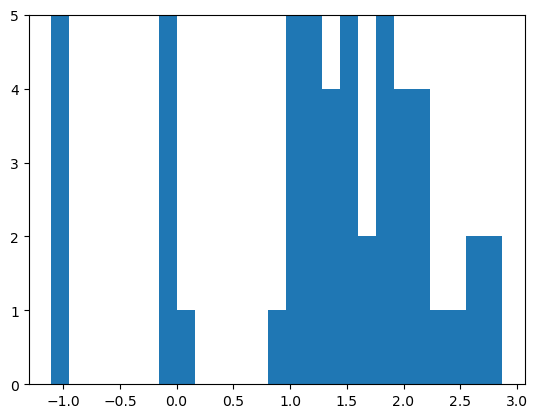

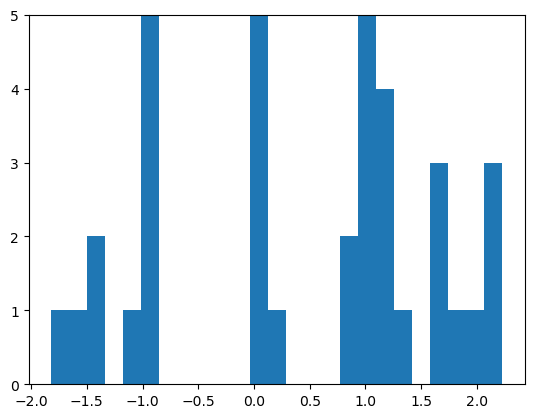

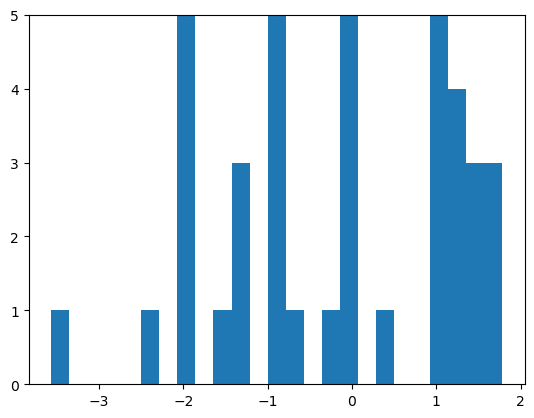

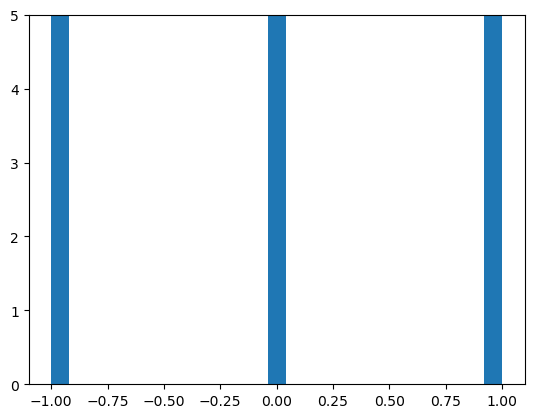

In [33]:
for param in optimizer.regularized_params:
    plt.hist(param.flatten().detach().cpu(),bins=25)
    plt.ylim((0,5))
    plt.show()

In [30]:
for param in optimizer.param_groups[-1]["params"]:
    print(param.shape)

torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 16, 1, 1])
torch.Size([16])
torch.Size([16])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 32, 1, 1])
torch.Size([32])
torch.Size([32])
torch.Size([1, 64, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([1, 64, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([1, 64, 1, 1])
torch.Size([64])
torch.Size([64])
torch.Size([1, 64, 1, 1])
torch.Size([64

In [ ]:
hist, model,optimizer = longrun_scale_layer(5e-4,{},"long2k-reg")

In [ ]:
res = []
for i in range(5):
    res_once = {}
    for beta in [1e-2,5e-3,1e-3,5e-4,1e-4]:
        hist, model, optimizer = longrun_scale_layer(beta,"test_betDec_fix_momReb_test_lritem_no_betaschedule")
        res_once[beta]= hist
    res.append(res_once)

In [ ]:
betas = res[0].keys()
for beta in betas:
    accs = [res[i][beta]["test_acc"][-1] for i in range(len(res))]
    print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

0.01 [90.33, 90.55, 90.15, 90.52, 90.53] 90.41600036621094 0.029979677870869637 

0.005 [91.03, 90.67, 90.71, 90.72, 90.32] 90.69000244140625 0.06354987621307373 

0.001 [91.74, 91.44, 91.7, 91.69, 91.86] 91.68599700927734 0.023479677736759186 

0.0005 [92.15, 91.92, 91.42, 91.87, 91.59] 91.78999328613281 0.0824509710073471 

0.0001 [91.57, 91.29, 91.52, 91.51, 91.58] 91.49400329589844 0.013929947279393673

In [ ]:
hist, model,optimizer = longrun_scale_layer(8e-4,"fixed-netadecay")

In [ ]:
train_loader, val_loader = create_data_loaders(
            "~/data",
            64,
            11,
            False,
            32,
        )
param_dict = {group["params"][0]:group for group in optimizer.param_groups if len(group["params"])==1 }
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
print(evaluate(model,val_loader,criterion,DEVICE))
# rebalance_layers(model,param_dict,factor_function=factor_function_test)
print(evaluate(model,val_loader,criterion,DEVICE))

In [ ]:
dir(model.conv1)

In [ ]:
names = {param:name for name,param in model.named_parameters()}

In [ ]:
for param_group in optimizer.param_groups:
    name = [names[param_group["params"][i]] for i in range(len(param_group["params"]))]
    print(name,param_group.get("weight_decay",0),param_group.get("lr",0),param_group.get("weight_decay",0) * param_group.get("lr",0) )
    print()

In [ ]:
model.linear[1].scale.mean()

In [ ]:

plt.hist(model.conv1[0].weight.detach().cpu().flatten(),bins = 40)